<a href="https://colab.research.google.com/github/aldinodemetrio-ai/Materiais_Alunos_EAD/blob/main/Visualiza%C3%A7%C3%A3o_de_Tend%C3%AAncias_de_Consumo_Energ%C3%A9tico_no_Pal%C3%A1cio_do_Jaburu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configuração visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [2]:
import pandas as pd

# Carregar arquivo CSV do GitHub, pois o arquivo Excel local não foi encontrado.
# Este método já foi testado e funcionou anteriormente para este dataset.
df = pd.read_csv('https://raw.githubusercontent.com/AndersonSalata/Materiais_Alunos_EAD/main/consumo-de-energia-eletrica-no-palacio-do-jaburu-2017-2024-setembro.csv', encoding='latin1', sep=';')

# Visualizar primeiras linhas
display(df.head())

# Informações do dataset
df.info()

,ANO,MÊS,CONSUMO-KWH,VALOR BRUTO DA FATURA
0,2017,Junho,27530,"R$ 17.910,77"
1,2017,Julho,30343,"R$ 17.686,84"
2,2017,Agosto,30997,"R$ 19.449,47"
3,2017,Setembro,36316,"R$ 21.949,20"
4,2017,Outubro,33980,"R$ 21.031,11"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ANO                      88 non-null     int64 
 1   MÊS                      88 non-null     object
 2   CONSUMO-KWH              88 non-null     int64 
 3    VALOR BRUTO DA FATURA   88 non-null     object
dtypes: int64(2), object(2)
memory usage: 2.9+ KB


In [3]:
# Verificar nomes das colunas
print(df.columns)

# Mapping of Portuguese month names to numbers
mes_para_numero = {
    'Janeiro': 1, 'Fevereiro': 2, 'Março': 3, 'Abril': 4, 'Maio': 5, 'Junho': 6,
    'Julho': 7, 'Agosto': 8, 'Setembro': 9, 'Outubro': 10, 'Novembro': 11, 'Dezembro': 12
}

# Create a temporary 'Mes_Numero' column by mapping month names to numbers
df['Mes_Numero'] = df['MÊS'].map(mes_para_numero)

# Combine 'ANO' (year) and 'Mes_Numero' (numeric month) to form a date string 'YYYY-MM-DD'
# Assume day '01' for simplicity
date_strings = df['ANO'].astype(str) + '-' + df['Mes_Numero'].astype(str) + '-01'

# Convert the combined date strings to datetime objects and assign back to 'MÊS' column
df['MÊS'] = pd.to_datetime(date_strings)

# Drop the temporary 'Mes_Numero' column
df = df.drop(columns=['Mes_Numero'])

# Criar colunas auxiliares 'Ano' and 'Mes_Num' from the new 'MÊS' datetime column
df['Ano'] = df['MÊS'].dt.year # This creates a new 'Ano' column (lowercase 'a')
df['Mes_Num'] = df['MÊS'].dt.month # This creates a 'Mes_Num' column

Index(['ANO', 'MÊS', 'CONSUMO-KWH', ' VALOR BRUTO DA FATURA '], dtype='object')


In [4]:
# Converter coluna da fatura para número
df['VALOR BRUTO DA FATURA_NUM'] = (
    df[' VALOR BRUTO DA FATURA ']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Verificar resultado
df[[' VALOR BRUTO DA FATURA ', 'VALOR BRUTO DA FATURA_NUM']].head()

,VALOR BRUTO DA FATURA,VALOR BRUTO DA FATURA_NUM
0,"R$ 17.910,77",17910.77
1,"R$ 17.686,84",17686.84
2,"R$ 19.449,47",19449.47
3,"R$ 21.949,20",21949.20
4,"R$ 21.031,11",21031.11


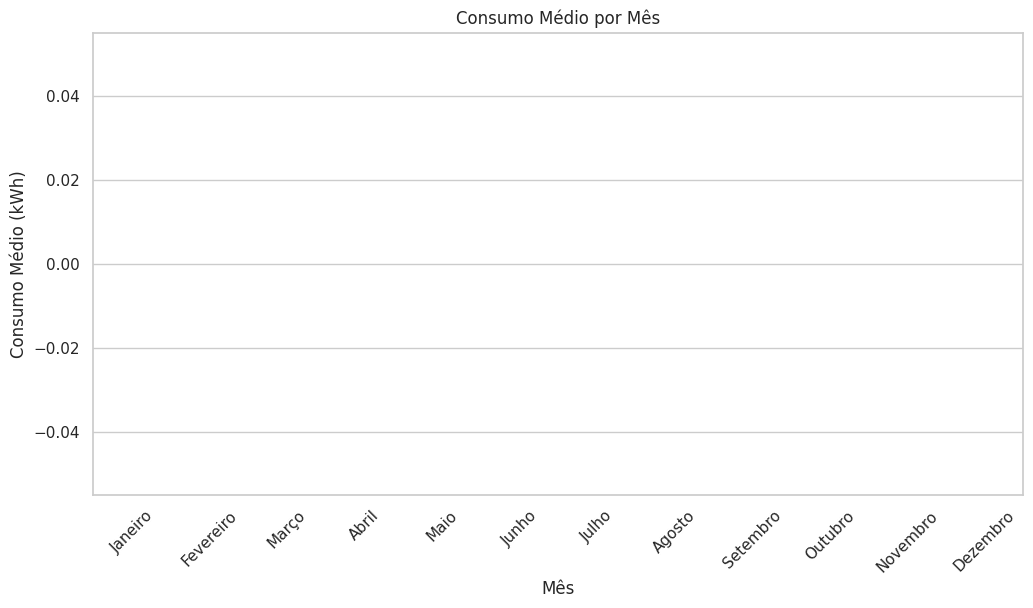

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Média mensal de consumo
media_mensal = (
    df.groupby('MÊS')['CONSUMO-KWH']
    .mean()
    .reset_index()
)

# Ordenar os meses corretamente
ordem_meses = [
    'Janeiro', 'Fevereiro', 'Março', 'Abril',
    'Maio', 'Junho', 'Julho', 'Agosto',
    'Setembro', 'Outubro', 'Novembro', 'Dezembro'
]

media_mensal['MÊS'] = pd.Categorical(
    media_mensal['MÊS'],
    categories=ordem_meses,
    ordered=True
)

media_mensal = media_mensal.sort_values('MÊS')

# Criar gráfico
plt.figure(figsize=(12,6))

sns.barplot(
    x='MÊS',
    y='CONSUMO-KWH',
    data=media_mensal
)

# Títulos
plt.title('Consumo Médio por Mês')
plt.xlabel('Mês')
plt.ylabel('Consumo Médio (kWh)')

# Rotacionar nomes dos meses
plt.xticks(rotation=45)

plt.show()

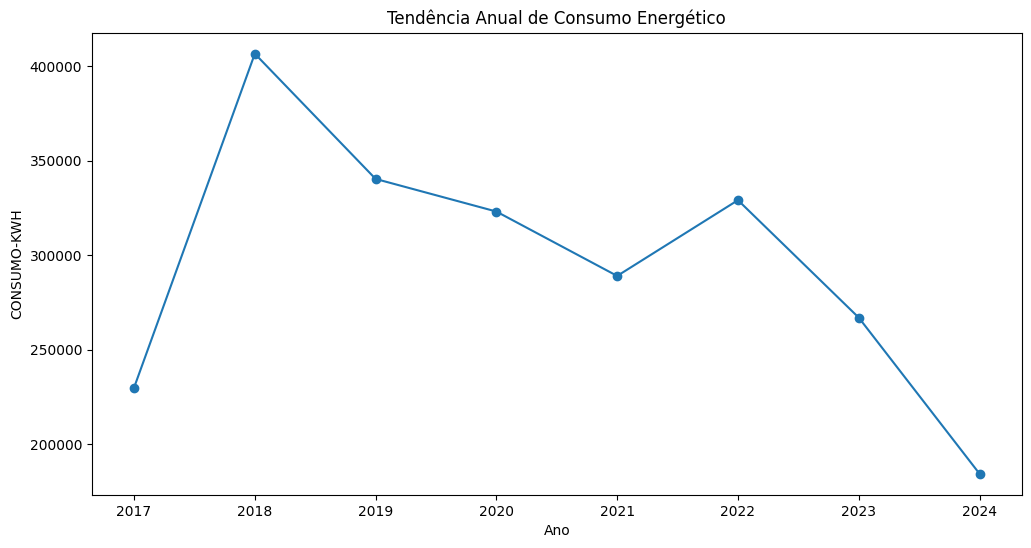

In [ ]:
# Agrupamento anual
consumo_anual = df.groupby('Ano')['CONSUMO-KWH'].sum().reset_index()

# Gráfico de linha
plt.figure(figsize=(12,6))

plt.plot(
    consumo_anual['Ano'],
    consumo_anual['CONSUMO-KWH'],
    marker='o'
)

plt.title('Tendência Anual de Consumo Energético')
plt.xlabel('Ano')
plt.ylabel('CONSUMO-KWH')

plt.show()

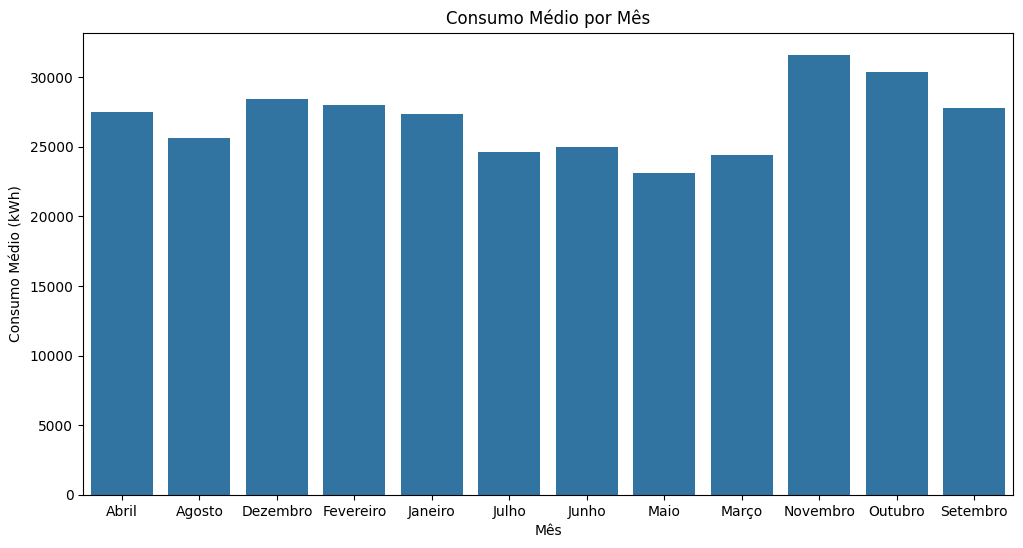

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Consumo médio por mês
media_mensal = df.groupby('MÊS')['CONSUMO-KWH'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(12,6))

sns.barplot(
    x='MÊS',
    y='CONSUMO-KWH',
    data=media_mensal
)

plt.title('Consumo Médio por Mês')
plt.xlabel('Mês')
plt.ylabel('Consumo Médio (kWh)')

plt.show()

             CONSUMO-KWH  VALOR_NUM
CONSUMO-KWH     1.000000   0.623752
VALOR_NUM       0.623752   1.000000


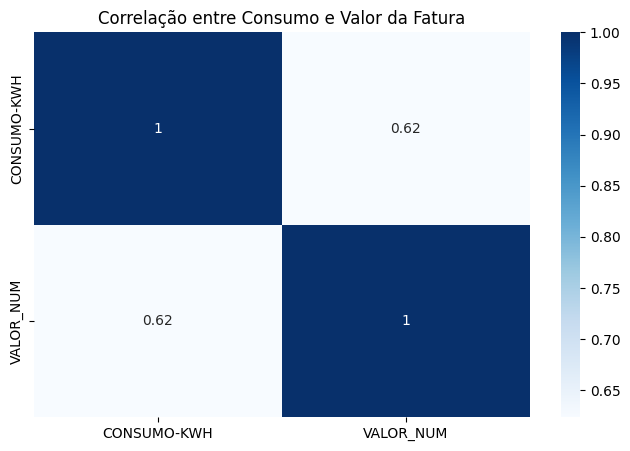

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Converter valor da fatura para número
df['VALOR_NUM'] = (
    df[' VALOR BRUTO DA FATURA ']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Correlação
correlacao = df[['CONSUMO-KWH', 'VALOR_NUM']].corr()

# Mostrar resultado
print(correlacao)

# Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='Blues'
)

plt.title('Correlação entre Consumo e Valor da Fatura')

plt.show()


             CONSUMO-KWH  VALOR_NUM
CONSUMO-KWH     1.000000   0.623752
VALOR_NUM       0.623752   1.000000


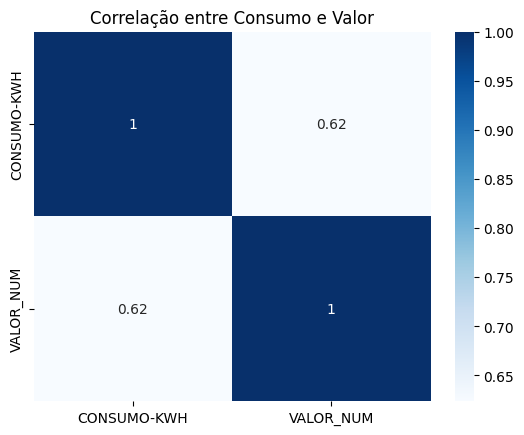

In [ ]:
print(correlacao)

# Heatmap
sns.heatmap(correlacao,
            annot=True,
            cmap='Blues')

plt.title('Correlação entre Consumo e Valor')
plt.show()

In [ ]:
import plotly.express as px

fig = px.line(
    df,
    x='MÊS',
    y='CONSUMO-KWH',
    title='Consumo Energético Interativo'
)

fig.show()

In [ ]:
# Consumo anual
consumo_anual = df.groupby('ANO')['CONSUMO-KWH'].sum().reset_index()

# Calcular diferença entre anos
consumo_anual['Diferença'] = consumo_anual['CONSUMO-KWH'].diff()

# Mostrar tabela
print(consumo_anual)

    ANO  CONSUMO-KWH  Diferença
0  2017       229830        NaN
1  2018       406657   176827.0
2  2019       340356   -66301.0
3  2020       323081   -17275.0
4  2021       288993   -34088.0
5  2022       329116    40123.0
6  2023       266935   -62181.0
7  2024       184256   -82679.0
